In [30]:
# importing standard data and plotting libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# sklearn imports for ML models and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [22]:
# read the data
df = pd.read_csv('/home/artifex/Machine-Learning/Projects/Diabetes/diabetes_data.csv')

# quick check of what we're dealing with
print("Data Info:")
df.info()

print("\nChecking for nulls:")
print(df.isnull().sum())

print("\nData summary:")
print(df.describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Checking for nulls:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    

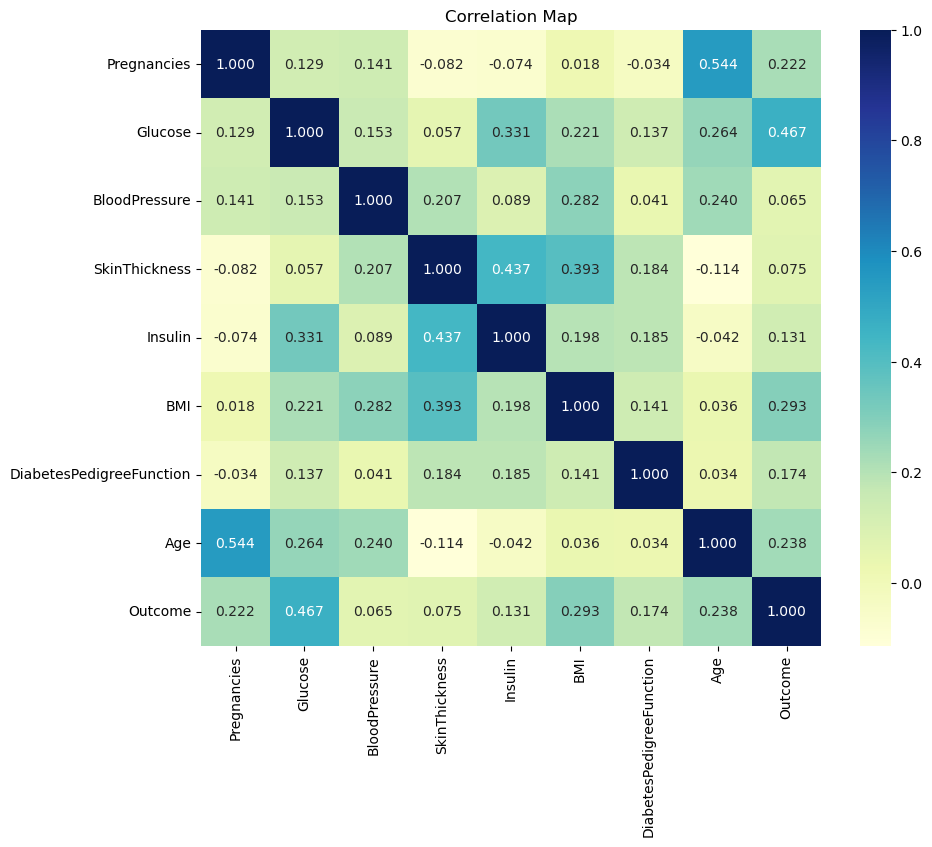

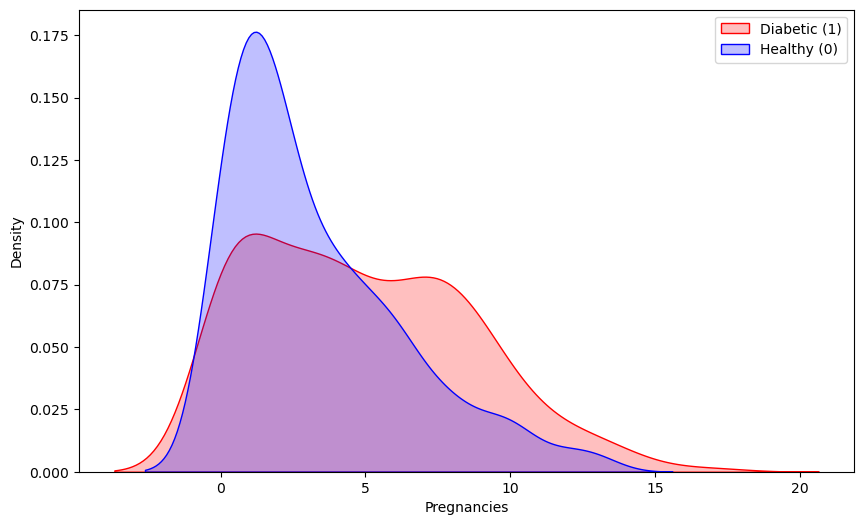

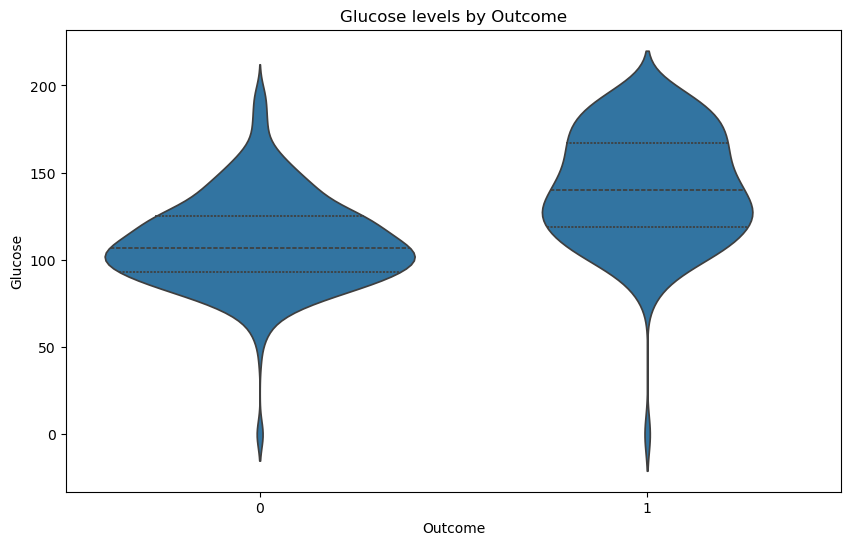

In [23]:
# let's look at how the features correlate with each other
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.3f', cmap='YlGnBu')
plt.title("Correlation Map")
plt.show()

# pregnancy distribution vs diabetes outcome
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Outcome'] == 1]['Pregnancies'], fill=True, color='red', label='Diabetic (1)')
sns.kdeplot(df[df['Outcome'] == 0]['Pregnancies'], fill=True, color='blue', label='Healthy (0)')
plt.xlabel("Pregnancies")
plt.ylabel("Density")
plt.legend()
plt.show()

# checking glucose levels using a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Outcome', y='Glucose', data=df, inner='quartile')
plt.title("Glucose levels by Outcome")
plt.show()

In [24]:
# You can't have 0 blood pressure or BMI, so these are actually missing values.
# Replacing the glucose 0s with the median, and the rest with the mean.
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['BMI'] = df['BMI'].replace(0, df['BMI'].mean())
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].mean())

In [25]:
# set up features (X) and target (y)
X = df.drop('Outcome', axis=1) 
y = df['Outcome']

# splitting into train and test sets (using 33% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

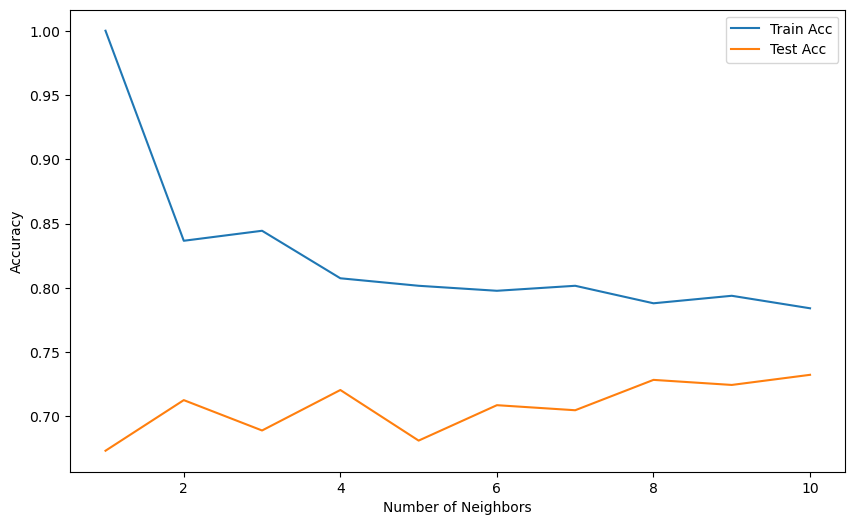

Final KNN Train Accuracy: 0.784
Final KNN Test Accuracy: 0.732


In [26]:
train_acc = []
test_acc = []
neighbors = range(1, 11)

# testing out 1 to 10 neighbors to see what works best
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

# plotting the accuracy to find the sweet spot
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_acc, label="Train Acc")
plt.plot(neighbors, test_acc, label="Test Acc")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# based on the plot, K=10 performs well without dropping off
knn_final = KNeighborsClassifier(n_neighbors=10)
knn_final.fit(X_train, y_train)
print(f"Final KNN Train Accuracy: {knn_final.score(X_train, y_train):.3f}")
print(f"Final KNN Test Accuracy: {knn_final.score(X_test, y_test):.3f}")

In [27]:
# testing a base tree first
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print(f"\nBase Tree Train Acc: {tree.score(X_train, y_train):.3f}")
print(f"Base Tree Test Acc: {tree.score(X_test, y_test):.3f}")

# The base tree is over-fitting (gives 100% on train), so limit the depth to 3
tree_tuned = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_tuned.fit(X_train, y_train)
print(f"Tuned Tree Train Acc: {tree_tuned.score(X_train, y_train):.3f}")
print(f"Tuned Tree Test Acc: {tree_tuned.score(X_test, y_test):.3f}")


Base Tree Train Acc: 1.000
Base Tree Test Acc: 0.681
Tuned Tree Train Acc: 0.774
Tuned Tree Test Acc: 0.693


In [28]:
# Neural nets need scaled data to work properly
scaler = StandardScaler()

# fit/transform the train data, but ONLY transform the test data 
# so we don't accidentally leak test info into the training process
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# training the MLP (added max_iter=1000 to fix a random convergence warning)
mlp = MLPClassifier(random_state=42, max_iter=1000) 
mlp.fit(X_train_scaled, y_train)

print(f"\nMLP Train Acc: {mlp.score(X_train_scaled, y_train):.3f}")
print(f"MLP Test Acc: {mlp.score(X_test_scaled, y_test):.3f}")


MLP Train Acc: 0.928
MLP Test Acc: 0.728


/home/artifex/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
